# Publaynet dataset
This dataset is used to recognize the tables 

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/208 [00:00<?, ?it/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

KEYS:  dict_keys(['image', 'id', 'annotations'])
{'annotations': [{'area': 23461.10391623131,
                  'bbox': [56.82, 337.9, 240.49, 105.59],
                  'category_id': 1,
                  'id': 1757180,
                  'image_id': 181168,
                  'iscrowd': 0,
                  'segmentation': [[...]]},
                 {'area': 11599.082233035006,
                  'bbox': [56.82, 453.47, 240.49, 53.02],
                  'category_id': 1,
                  'id': 1757181,
                  'image_id': 181168,
                  'iscrowd': 0,
                  'segmentation': [[...]]},
                 {'area': 17795.1634452499,
                  'bbox': [315.3, 337.99, 240.51, 74.0],
                  'category_id': 1,
                  'id': 1757182,
                  'image_id': 181168,
                  'iscrowd': 0,
                  'segmentation': [[...]]},
                 {'area': 13629.97964575002,
                  'bbox': [315.3, 442.9, 240.49, 

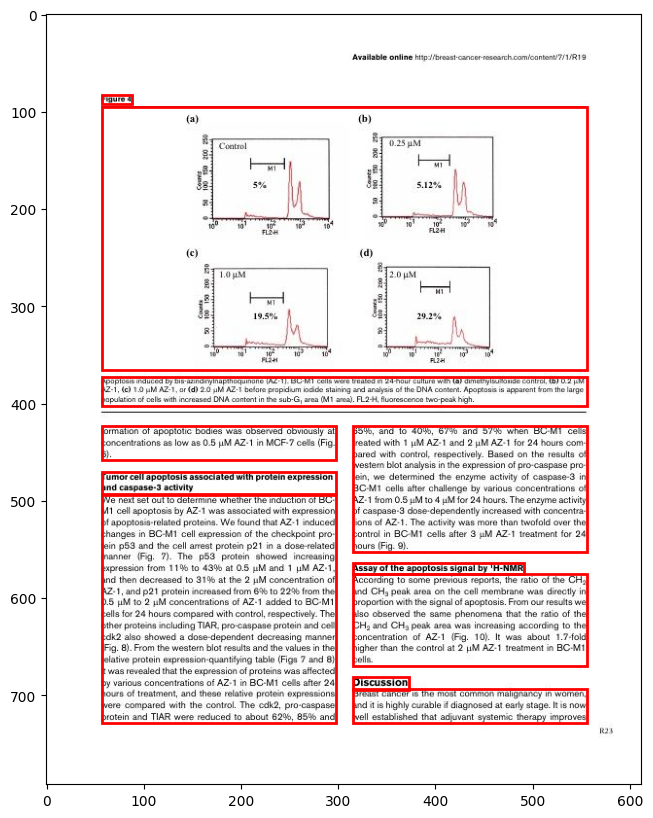

In [1]:
#  The dataset is being prepared
from datasets import load_dataset
import pprint
from datasets import Dataset
import matplotlib.pyplot as plt #This is used to build the actual white canvas for the image to put
import matplotlib.patches as patches 

# Streamlining the pyblaynet dataset from hugging face datasets library
ds = load_dataset(
    "jordanparker6/publaynet",
    split="train",
    streaming=True
)

# inspecting few samples
for i, sample in enumerate(ds):

    print("KEYS: ", sample.keys())
    
    # depth usually means the number of boxes I want to go inside
    pprint.pprint(sample,depth = 4)

    if i == 2:
        break

# Taking 1001 raw data from the dataset and storing in the form of list
small_samples = []
for i, sample in enumerate(ds):
    small_samples.append(sample)

    if i >= 1000:
        break

# converting the python list to a hugging face dataset
small_ds = Dataset.from_list(small_samples)

# Visualizing the 3rd image 
sample = small_ds[3] 

image = sample["image"]
annotations = sample["annotations"]

# fig = figure and ax = axes 
# fig is the window that holds everything if I want to change the color or save the image then I can use fig
# ax is the plot the graphing area containing the x-axis, and the y-axis, the gridlines and the data.
fig, ax = plt.subplots(figsize=(10,10))

# imshow() method is desinged to render 2d pictures 
ax.imshow(image)

for annotation in annotations:
    x, y, w, h = annotation["bbox"]
    rect = patches.Rectangle(
        (x, y),
        w, 
        h,
        linewidth=2,
        # edgecolor defines the border of the rectangle
        edgecolor='red',
        # facecolor defines the inside of the rectangle
        facecolor='none' 
    )
    ax.add_patch(rect)

plt.show()

In [2]:
# Prepreocessing of the prepared dataset and preparing the dataloaders

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F
from torchvision.transforms import v2
from datasets import load_dataset
from torchvision import tv_tensors


# The hugging face dataSet are already parsed 
class publayNetDataset(Dataset):
    def __init__(self, small_ds, transform):
        self.small_ds = small_ds
        self.transform = transform
    
    def __len__(self):
        return len(self.small_ds)

    # Bundle the python box and label tensors into python dictionary
    # Finally return the processed image tensor and the target dictionary 

     # Below function load a image using ovencv or PIL library
    def __getitem__(self, index):
        sample = self.small_ds[index]
        image = sample['image']
        
        # annotations
        annotations = sample['annotations']

        boxes = []
        labels = []
        
        # finds labels and bbox with that particular image
        for ann in annotations:
            bbox = ann['bbox']
            category = ann['category_id']

            x_min, y_min, w, h = bbox
            x_max = x_min + w
            y_max = y_min + h

            # stored each coordinate of boxes in python list
            if w>0 and h>0:
                boxes.append([x_min, y_min, x_max, y_max])
                labels.append(category)

        # Ensure the box has width and height greater than 0 
        # Convert the python list into tensors, boxes into float tensors and labels into integer tensors
        if len(boxes) > 0:
            boxes_tensor = torch.as_tensor(boxes, dtype = torch.float32)
        else:
            boxes_tensor = torch.empty((0, 4), dtype = torch.float32)
            
        label_tensor = torch.as_tensor(labels, dtype = torch.int64) 

        # wrapping the tensor so v2 knows those coordinates are bouding boxes So it can resize them as well
        W, H = image.size
        boxes_tensor = tv_tensors.BoundingBoxes(
            boxes_tensor,
            format="XYXY",
            canvas_size=(H,W)
        )
        
        # Wrapping the tensor objects in the dictionaries
        target = {
            "boxes": boxes_tensor,
            "labels": label_tensor
        }
        
        # Pass the loaded image through transformation pipeline for resizing and normalization
        if hasattr(self, 'transform') and self.transform is not None:
            image, target = self.transform(image, target)
        else:
            image = F.to_tensor(image)
                
        return image, target


# initializing the transform pipeline
my_detection_transforms = v2.Compose([
    v2.ToImage(),  # Converts image into tensor image wrapper          
    v2.Resize(size=(800, 800)), # Resizes image and automatically scales bounding boxes
    v2.ToDtype(torch.float32, scale=True) # Normalizes to [0, 1] range
])

# instantiating the dataset
dataset = publayNetDataset(
    small_ds = small_ds, 
    transform = my_detection_transforms
)

def crnn_collate_fn(batch):
    images = []
    targets = []

    # Loop through the batch
    for image, target in batch:
        images.append(image)
        targets.append(target)

    # Stack the images into a single batch tensor (Only works if they are all resized to the same size!)
    images_tensor = torch.stack(images)

    # Leave targets exactly as they are: a list of dictionaries!
    return images_tensor, targets

# plug it into the dataLoader
my_dataloader = DataLoader(
    dataset=dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=crnn_collate_fn
)

--- BATCH STRUCTURE ---
Number of images stacked: 32
Stacked Images Tensor Shape: torch.Size([32, 3, 800, 800])
Number of target dictionaries: 32
Target 0 Keys: dict_keys(['boxes', 'labels'])

Found 9 tables/objects in Image 0.


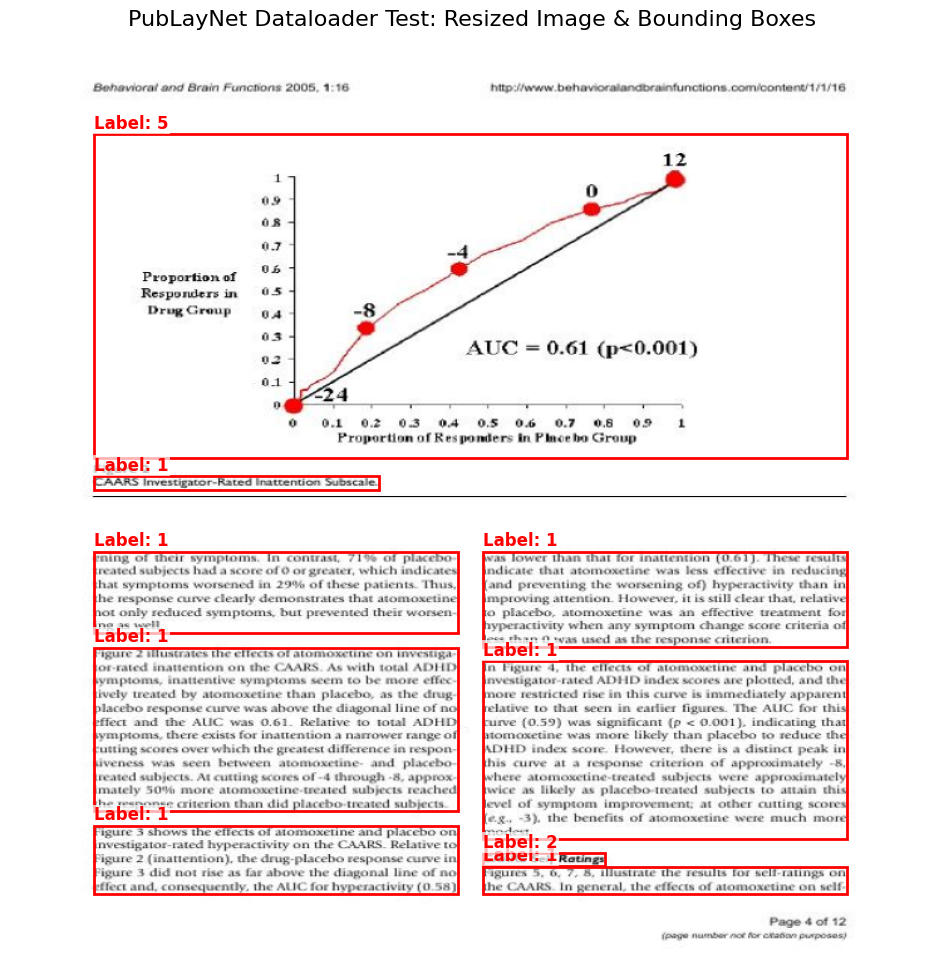

In [3]:
# Testing the preprocessed dataset

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

# 1. Grab a single batch of data from your dataloader
# iter() turns the dataloader into an iterator, next() pulls the first batch
images, targets = next(iter(my_dataloader))

# 2. Print the architecture of the batch to verify collate_fn
print("--- BATCH STRUCTURE ---")
print(f"Number of images stacked: {len(images)}")
print(f"Stacked Images Tensor Shape: {images.shape}") # Expected: [32, C, 800, 800]
print(f"Number of target dictionaries: {len(targets)}") # Expected: 32
print(f"Target 0 Keys: {targets[0].keys()}")

# 3. Extract the very first image and its matching target dictionary
image_0 = images[0]
target_0 = targets[0]

# PyTorch images are formatted as [Channels, Height, Width] (e.g., [3, 800, 800])
# Matplotlib requires images to be [Height, Width, Channels] to plot them.
# .permute(1, 2, 0) reshuffles the dimensions for us.
image_to_plot = image_0.permute(1, 2, 0).numpy()

# 4. Set up the matplotlib plot
fig, ax = plt.subplots(1, figsize=(12, 12))
ax.imshow(image_to_plot)

# 5. Extract the boxes and labels from the target dictionary
boxes = target_0["boxes"].numpy()
labels = target_0["labels"].numpy()

# 6. Loop through every box in the image and draw it
print(f"\nFound {len(boxes)} tables/objects in Image 0.")
for box, label in zip(boxes, labels):
    # Unpack the XYXY coordinates
    x_min, y_min, x_max, y_max = box
    
    # Matplotlib needs width and height to draw a rectangle
    width = x_max - x_min
    height = y_max - y_min
    
    # Create the red bounding box
    rect = patches.Rectangle(
        (x_min, y_min), width, height, 
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)
    
    # Add the label number right above the box
    ax.text(
        x_min, y_min - 5, f"Label: {label}", 
        color='red', fontsize=12, weight='bold', 
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
    )

plt.title("PubLayNet Dataloader Test: Resized Image & Bounding Boxes", fontsize=16)
plt.axis('off')
plt.show()

# MJSynth DataSet

This dataset will be used to identify the text below the preprocessing of the dataset will be done

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

keys dict_keys(['image', 'label'])
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=72x31 at 0x7C1D67F21190>,
 'label': 'Lube'}
keys dict_keys(['image', 'label'])
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=82x31 at 0x7C1D67F21100>,
 'label': 'Spencerian'}
keys dict_keys(['image', 'label'])
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=115x31 at 0x7C1D67F20E30>,
 'label': 'accommodatingly'}


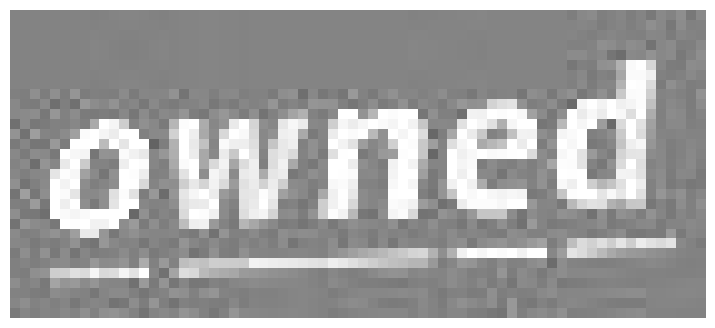

In [4]:
#  Loading and preparing the dataset 

from datasets import load_dataset
import pprint
from datasets import Dataset
import matplotlib.pyplot as plt


ds2 = load_dataset(
    "priyank-m/MJSynth_text_recognition",
     split= "train",
     streaming = True
)

# Inspecting the few samples 
for i, sample in enumerate(ds2):
    print("keys", sample.keys())

    pprint.pprint(sample, depth=2)

    if i == 2:
        break


# Storing 1000 dataset in form of python list
small_sample = []
for i, sample in enumerate(ds2):
    small_sample.append(sample)

    if i > 999:
        break


# Convert the python list into hugginf face dataset
small_ds2 = Dataset.from_list(small_sample)

# Visualizing one image
sample = small_ds2[230]
image = sample["image"]

# Plot the image in the 10*10 plot
# fig can be used to change the color or save the image 
# ax can be used to make changes in axes
fig, ax = plt.subplots(figsize = (10, 4))

# to plot the image 
ax.imshow(image)
ax.axis('off')
plt.show()


In [5]:
# The preprocessing of the dataset is done here

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms.functional as F
import torchvision.transforms as T
from datasets import load_dataset

# Cleaning the dataset
unique_chars = sorted(list(set("".join(small_ds2["label"])))) # Takes whole row of feature label and extracts the unique characters and stores in form of list.
my_dictionary = {char: idx for idx, char in enumerate(unique_chars, start=1)} # Build the dictionary with index 0 reserved for the CTC token

# Instantiating a transform pipeline
my_transform_pipeline = T.Compose([
    T.Resize((32, 128)), 
    T.ToTensor()
])

# create the custom collection function
class MJSynthDataset(Dataset):
    def __init__(self, small_ds2, char_to_idx_dict, transform=None):
        self.small_ds2 = small_ds2
        self.char_to_idx_dict = char_to_idx_dict
        self.transform = transform

    def __len__(self):
        return len(self.small_ds2)

    def __getitem__(self, index):
        sample = self.small_ds2[index] # Grapping a sample from the dataset
        image = sample["image"]
        label = sample["label"]

        # If transform pipeline is passed as argument then pass the image through the transform pipeline 
        if self.transform is not None:
            image_tensor = self.transform(image)
        else:
            # If no transform pipeline is provided then convert the image into tensor object
            image_tensor = F.to_tensor(image)

        # convert characters into integers_id
        integer_ids = []
        for char in label:
            index = self.char_to_idx_dict.get(char, 0)
            integer_ids.append(index)

        label_tensor = torch.tensor(integer_ids, dtype=torch.int64)

        # Return the processed pieces
        return image_tensor, label_tensor

# create collate fn different label tensors sizes and convert them to the same length
# pytorch will hand the batch automatically whatever the getitem returns
def crnn_collate_fn(batch):
    images = []
    labels = []
    labels_length = []

    # unpack the list of tuples 
    for image_tensor, label_tensor in batch:
        images.append(image_tensor)
        labels.append(label_tensor)
        labels_length.append(len(label_tensor))

    images_tensor = torch.stack(images) # This line simply adds images on top of each  
    labels_padded = pad_sequence(labels, batch_first=True, padding_value=0) # This line adds filler values to the shorter labels so all the labels same values
    labels_lengths_tensor = torch.tensor(labels_length, dtype=torch.int64) # THis line simply converts the length into tensor objects
    return images_tensor, labels_padded, labels_lengths_tensor


# initialize the dataset class 
dataset2 = MJSynthDataset (
    small_ds2=small_ds2,
    char_to_idx_dict=my_dictionary,
    transform=my_transform_pipeline
)


# plug it into the dataLoader
my_dataloader = DataLoader(
    dataset=dataset2,
    batch_size=32,
    shuffle=True,
    collate_fn=crnn_collate_fn
)

--- BATCH STRUCTURE ---
Stacked Images Tensor Shape: torch.Size([32, 3, 32, 128])
Padded Labels Tensor Shape: torch.Size([32, 14])
Lengths Tensor Shape: torch.Size([32])

Original sequence length (before padding): 6
Decoded Tensor Output: BETCHA[PAD/BLANK][PAD/BLANK][PAD/BLANK][PAD/BLANK][PAD/BLANK][PAD/BLANK][PAD/BLANK][PAD/BLANK]


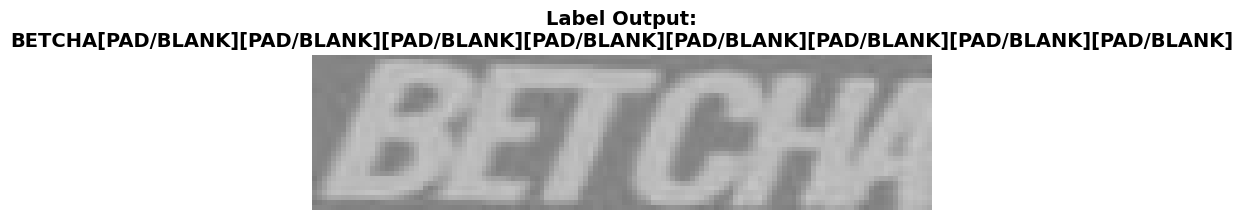

In [6]:
# Testing the preprocessed dataset 

import matplotlib.pyplot as plt
import torch

# 1. Create a reverse dictionary to turn integers back into characters
# We need this to read what the tensor is actually saying
idx_to_char_dict = {idx: char for char, idx in my_dictionary.items()}
# Add a placeholder for 0 so it prints nicely instead of throwing an error
idx_to_char_dict[0] = "[PAD/BLANK]" 

# 2. Grab a single batch of data from your dataloader
# iter() turns the dataloader into an iterator, next() pulls the first batch
images, labels_padded, labels_lengths = next(iter(my_dataloader))

# 3. Print the architecture of the batch to verify collate_fn worked
print("--- BATCH STRUCTURE ---")
print(f"Stacked Images Tensor Shape: {images.shape}") # Expected: [32, C, 32, 128]
print(f"Padded Labels Tensor Shape: {labels_padded.shape}") # Expected: [32, max_length_in_this_batch]
print(f"Lengths Tensor Shape: {labels_lengths.shape}") # Expected: [32]

# 4. Extract the very first item in the batch
image_0 = images[0]
label_0 = labels_padded[0]
length_0 = labels_lengths[0]

# 5. Decode the padded tensor back into readable text
decoded_text_list = []
for idx in label_0.numpy():
    decoded_text_list.append(idx_to_char_dict[idx])
    
decoded_text = "".join(decoded_text_list)
print(f"\nOriginal sequence length (before padding): {length_0}")
print(f"Decoded Tensor Output: {decoded_text}")

# 6. Set up the matplotlib plot to visually check the image
# PyTorch images are [Channels, Height, Width]. Matplotlib wants [Height, Width, Channels]
image_to_plot = image_0.permute(1, 2, 0).numpy()

plt.figure(figsize=(8, 3))
# If it's a 1-channel grayscale image, squeeze it for matplotlib
if image_to_plot.shape[-1] == 1:
    plt.imshow(image_to_plot.squeeze(), cmap='gray')
else:
    plt.imshow(image_to_plot)

plt.title(f"Label Output:\n{decoded_text}", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()